In [59]:
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

thermal_config_path = Path('config/stn2024_thermal.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

N_timesteps = 120

lat, lon = 81.579433, -16.6454085

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2024-04-01T10:00:00', periods=N_timesteps, freq='300s'),
        'latitude' : ('time', [lat] * N_timesteps),
        'longitude' : ('time', [lon] * N_timesteps),
        'altitude' : ('altitude', [0.0]),
    },
    data_vars={
        'surface_temperature' : ('time', [275.15] * N_timesteps),  # Kelvin
    }
)

ds

<xarray.Dataset> Size: 4kB
Dimensions:              (time: 120, altitude: 1)
Coordinates:
  * time                 (time) datetime64[ns] 960B 2024-04-01T10:00:00 ... 2...
    latitude             (time) float64 960B 81.58 81.58 81.58 ... 81.58 81.58
    longitude            (time) float64 960B -16.65 -16.65 ... -16.65 -16.65
  * altitude             (altitude) float64 8B 0.0
Data variables:
    surface_temperature  (time) float64 960B 275.1 275.1 275.1 ... 275.1 275.1

In [28]:
ds_rs = xr.open_mfdataset(glob.glob('/projekt_agmwend/home_rad/Joshua/STN2024/RS_STN/radiosonde_netcdf/*.nc'), combine='by_coords')

/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_3517185/1010185677.py:1: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_rs = xr.open_mfdataset(glob.glob('/projekt_agmwend/home_rad/Joshua/STN2024/RS_STN/radiosonde_netcdf/*.nc'), combine='by_coords')
/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_3517185/1010185677.py:1: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute b

In [29]:
ds_rs

<xarray.Dataset> Size: 12MB
Dimensions:            (time: 204187)
Coordinates:
  * time               (time) datetime64[ns] 2MB 2024-03-21T14:45:17.700000 ....
Data variables:
    time_since_launch  (time) timedelta64[ns] 2MB dask.array<chunksize=(8659,), meta=np.ndarray>
    air_temperature    (time) float32 817kB dask.array<chunksize=(8659,), meta=np.ndarray>
    relative_humidity  (time) float32 817kB dask.array<chunksize=(8659,), meta=np.ndarray>
    tu_cap             (time) float32 817kB dask.array<chunksize=(8659,), meta=np.ndarray>
    distance           (time) float64 2MB dask.array<chunksize=(8659,), meta=np.ndarray>
    vertical_speed     (time) float32 817kB dask.array<chunksize=(8659,), meta=np.ndarray>
    wind_speed         (time) float32 817kB dask.array<chunksize=(8659,), meta=np.ndarray>
    longitude          (time) float32 817kB dask.array<chunksize=(8659,), meta=np.ndarray>
    latitude           (time) float32 817kB dask.array<chunksize=(8659,), meta=np.ndarray>
    altitude           (time) float64 2MB dask.array<chunksize=(8659,), meta=np.ndarray>
Attributes:
    title:        Radiosonde Sounding Data
    institution:  TROPOS / Leipzig Institute for Meteorology
    author_1:     Holger Siebert
    author_2:     Micheal Schäfer
    author_3:     Joshua Müller
    source:       Radiosonde ascent
    citation:     <citation>
    Conventions:  CF-1.8

In [ ]:
import glob
ds_ceilo = xr.open_dataset('/projekt_agmwend/data/Station_Nord_2024/Ceilometer/Ceilometer_STN_all.nc')

In [10]:
import xarray as xr
from datetime import datetime
from pyradtran.io_unified import RadiosondeAtmosphereGenerator
from pathlib import Path


# 2. Build a LibRadtran atmosphere file from the closest IGRA sounding
atm_path = RadiosondeAtmosphereGenerator.create_radiosonde_atmosphere_file(
    time=datetime(2023, 12, 30, 0),
    latitude=lat,
    longitude=lon,
    output_filepath="work/sonde_nya.dat",
)

In [72]:
ds_gp = ds_rs[['altitude', 'air_temperature', 'relative_humidity']].groupby('time.dayofyear')
atm_paths = []
for day, ds_day in ds_gp:
    print(f"Day {day}:")
    print(ds_day)
    date = ds_day['time'].dt.date.values[0]
    df_day = ds_day.to_dataframe().reset_index().dropna(how='any').sort_values(by='altitude', ascending=True).drop(columns=['time']).drop_duplicates()
    df_day['altitude'] /= 1000
    df_day['air_temperature'] += 273.15
    atm_name = f"work/stn2024_day_{date}.csv"
    df_day.to_csv(atm_name, index=False, header=False, sep='\t')
    atm_paths.append(atm_name)


Day 81:
<xarray.Dataset> Size: 446kB
Dimensions:            (time: 18584)
Coordinates:
  * time               (time) datetime64[ns] 149kB 2024-03-21T14:45:17.700000...
Data variables:
    altitude           (time) float64 149kB dask.array<chunksize=(8659,), meta=np.ndarray>
    air_temperature    (time) float32 74kB dask.array<chunksize=(8659,), meta=np.ndarray>
    relative_humidity  (time) float32 74kB dask.array<chunksize=(8659,), meta=np.ndarray>
Attributes:
    title:        Radiosonde Sounding Data
    institution:  TROPOS / Leipzig Institute for Meteorology
    author_1:     Holger Siebert
    author_2:     Micheal Schäfer
    author_3:     Joshua Müller
    source:       Radiosonde ascent
    citation:     <citation>
    Conventions:  CF-1.8
Day 82:
<xarray.Dataset> Size: 323kB
Dimensions:            (time: 13478)
Coordinates:
  * time               (time) datetime64[ns] 108kB 2024-03-22T07:33:08.900000...
Data variables:
    altitude           (time) float64 108kB dask.array<c

In [73]:
atm_paths[11]

'work/stn2024_day_2024-04-04.csv'

In [74]:
ds_sim_thermal = ds.isel(time=slice(0,2)).pyradtran.run(
    config_path=thermal_config_path,
    return_dataset=True,
    save_to_file=False,
    parameter_overrides={"atmosphere_file": str(atm_paths[10])},
)

2025-08-30 11:02:10,907 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig
2025-08-30 11:02:10,909 - pyradtran.config - WARNING - Ignoring unknown config parameter: aerosol_type in SimulationDefaults
2025-08-30 11:02:10,909 - pyradtran.config - WARNING - Ignoring unknown config parameter: aerosols in SimulationDefaults
2025-08-30 11:02:10,910 - pyradtran.config - WARNING - Ignoring unknown config parameter: albedo_file in SimulationDefaults
2025-08-30 11:02:10,910 - pyradtran.config - WARNING - Ignoring unknown config parameter: albedo_library in SimulationDefaults
2025-08-30 11:02:10,910 - pyradtran.config - WARNING - Ignoring unknown config parameter: albedo_type in SimulationDefaults
2025-08-30 11:02:10,910 - pyradtran.config - WARNING - Ignoring unknown config parameter: brdf_cam in SimulationDefaults
2025-08-30 11:02:10,911 - pyradtran.config - WARNING - Ignoring unknown config parameter: brdf_rpv in SimulationDefaults
2025-08-30 11

PyRadtranError: All simulations failed - no valid results produced

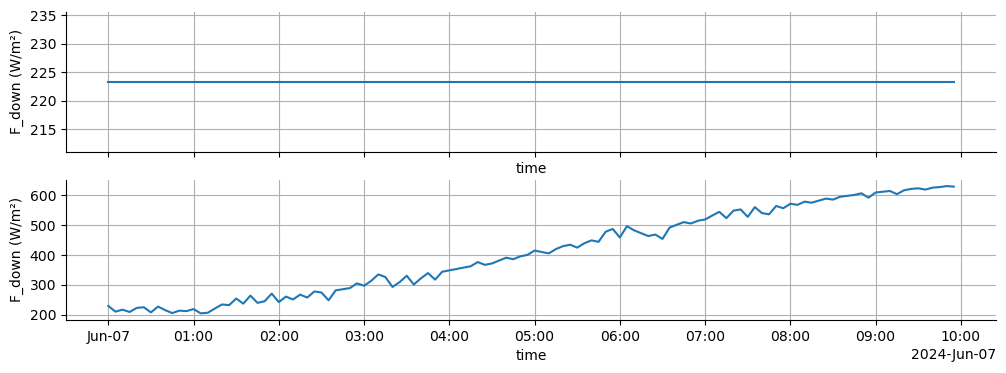

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(12, 4), sharex=True)

(ds_sim_solar.drop_vars(['latitude', 'longitude', 'altitude']).eglo / 1000).plot()
(ds_sim_thermal.drop_vars(['latitude', 'longitude', 'altitude']).eglo).plot(ax=ax[0])

for a in ax:
    a.set_ylabel('F_down (W/m²)')
    a.grid()
    a.spines[['top', 'right']].set_visible(False)

In [ ]:


# 3. Run pyradtran from the xarray accessor, overriding the atmosphere file
result_ds = ds.pyradtran.run(
    config_path=solar_config_path,
    parameter_overrides={"radiosonde": str(atm_path)+" H2O RH"},
    return_dataset=True,
    save_to_file=False,
)


2025-08-21 15:50:28,856 - pyradtran.io_unified - INFO - Created radiosonde atmosphere file: sonde_atm.dat
2025-08-21 15:50:28,867 - pyradtran.config - WARNING - Ignoring unknown config parameter: phi in SimulationDefaults
2025-08-21 15:50:28,867 - pyradtran.config - WARNING - Ignoring unknown config parameter: transmittance_source in SimulationDefaults
Running simulations: 100%|██████████| 1/1 [00:08<00:00,  8.23s/sim, Success=1, Total=1]
2025-08-21 15:50:37,100 - pyradtran.interface - INFO - Batch execution completed: 1/1 simulations successful
